# Documentation corpus findings

This notebook summarizes `documentation_files.jsonl` produced by `pull_documentation_files.py`. Each JSONL row represents one documentation file and includes its repository, branch, path, SHA, and text content.

It answers:

- How many repositories and documentation files were collected?
- Which filenames occur most often (for example, `README.md`, `SKILL.md`, and `AGENTS.md`)?
- Which repositories contain the most documentation files?
- Which extensions and directories are most common?
- How large is the collected documentation corpus, and are there duplicate file contents?

In [1]:
from __future__ import annotations

import hashlib
import json
from pathlib import Path, PurePosixPath

import matplotlib.pyplot as plt
import pandas as pd

INPUT_PATH = Path("documentation_files.jsonl")
TOP_N = 20

pd.set_option("display.max_colwidth", 100)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
# Load JSONL and retain malformed rows for a data-quality check.
if not INPUT_PATH.exists():
    raise FileNotFoundError(f"Could not find {INPUT_PATH.resolve()}")

records, invalid_rows = [], []
with INPUT_PATH.open(encoding="utf-8") as jsonl_file:
    for line_number, line in enumerate(jsonl_file, start=1):
        if not line.strip():
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError as exc:
            invalid_rows.append({"line": line_number, "error": str(exc)})

df = pd.DataFrame(records)
required_columns = {"repository", "repository_url", "branch", "path", "sha", "content"}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"JSONL is missing expected columns: {sorted(missing_columns)}")

df["path"] = df["path"].astype(str)
df["file_name"] = df["path"].map(lambda path: PurePosixPath(path).name)
df["file_name_normalized"] = df["file_name"].str.casefold()
df["extension"] = df["path"].map(lambda path: PurePosixPath(path).suffix.lower() or "[no extension]")
df["directory"] = df["path"].map(lambda path: str(PurePosixPath(path).parent))
df["is_root_file"] = df["directory"].eq(".")
df["content"] = df["content"].fillna("").astype(str)
df["characters"] = df["content"].str.len()
df["content_hash"] = df["content"].map(lambda text: hashlib.sha256(text.encode("utf-8")).hexdigest())

print(f"Loaded {len(df):,} documentation records from {INPUT_PATH}.")
print(f"Malformed non-empty JSONL rows: {len(invalid_rows):,}")
if invalid_rows:
    display(pd.DataFrame(invalid_rows).head())

Loaded 20,565 documentation records from documentation_files.jsonl.
Malformed non-empty JSONL rows: 0


## Corpus overview and data quality

In [3]:
summary = pd.Series({
    "Documentation files": len(df),
    "Repositories": df["repository"].nunique(),
    "Branches": df["branch"].nunique(),
    "Root-level files": int(df["is_root_file"].sum()),
    "Nested files": int((~df["is_root_file"]).sum()),
    "Total characters": int(df["characters"].sum()),
    "Median characters per file": int(df["characters"].median()),
    "Empty files": int(df["content"].eq("").sum()),
    "Duplicate-content records": int(df.duplicated("content_hash", keep=False).sum()),
})
display(summary.to_frame("value"))

# A duplicate source record indicates that a prior --resume run may have appended it.
duplicate_sources = df.duplicated(["repository", "branch", "path", "sha"], keep=False)
print(f"Duplicate source records: {duplicate_sources.sum():,}")
if duplicate_sources.any():
    display(df.loc[duplicate_sources, ["repository", "branch", "path", "sha"]].sort_values(["repository", "path"]).head(20))

,value
Documentation files,20565
Repositories,65
Branches,2
Root-level files,473
Nested files,20092
Total characters,180561622
Median characters per file,3756
Empty files,95
Duplicate-content records,1670


Duplicate source records: 0


## Most frequent filenames

Filenames are grouped case-insensitively, so `README.md` and `readme.md` count together. This is useful for spotting common repository conventions and guidance files.

,filename,files,repositories
7636,SKILL.md,2295,43
6800,README.md,1553,65
1515,agents.md,435,41
4576,index.md,287,19
7414,SECURITY.md,126,41
4577,index.mdx,105,8
7758,spec.md,99,2
6223,PLAN.md,92,11
7036,requirements.txt,90,25
8133,TESTING.md,83,12


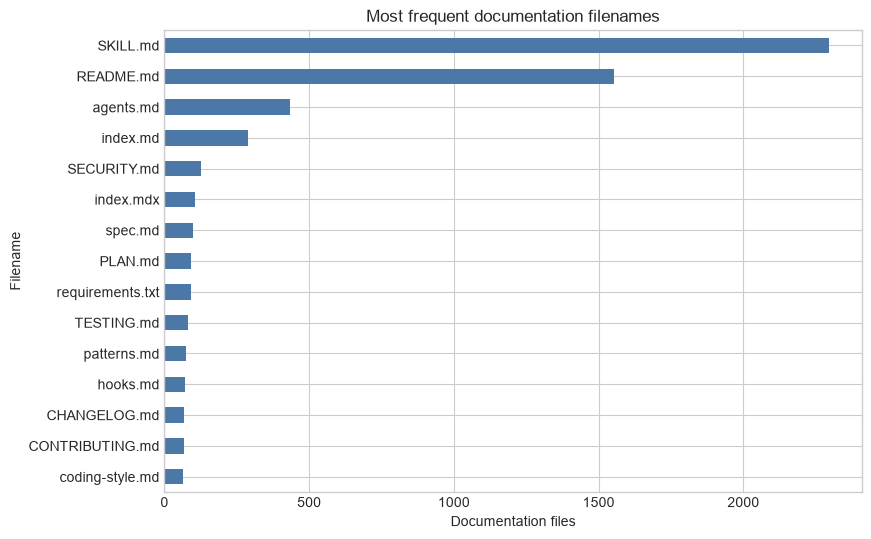

In [5]:
filename_counts = (
    df.groupby("file_name_normalized", as_index=False)
      .agg(files=("path", "size"), example_spelling=("file_name", "first"), repositories=("repository", "nunique"))
      .sort_values(["files", "repositories"], ascending=False)
)
display(filename_counts.head(TOP_N).rename(columns={"example_spelling": "filename"})[["filename", "files", "repositories"]])

guidance_names = ["agents.md", "skill.md", "claude.md", "contributing.md", "security.md", "readme.md"]
guidance_counts = filename_counts[filename_counts["file_name_normalized"].isin(guidance_names)]

chart_data = filename_counts.head(15).sort_values("files")
ax = chart_data.plot.barh(x="example_spelling", y="files", legend=False, figsize=(9, 6), color="#4C78A8")
ax.set(xlabel="Documentation files", ylabel="Filename", title="Most frequent documentation filenames")
plt.show()

## Repositories with the most documentation

The table combines document count, total corpus size, and the number of distinct directories. The last measure helps distinguish repositories with a few large docs from documentation distributed across the codebase.

,repository,repository_url,documentation_files,total_characters,median_characters,unique_directories,root_files
23,affaan-m/ECC,https://github.com/affaan-m/ECC,2545,13539821,3455,1097,18
51,ruvnet/ruflo,https://github.com/ruvnet/ruflo,1898,15377062,4732,794,8
11,NousResearch/hermes-agent,https://github.com/NousResearch/hermes-agent,1515,18433746,7641,469,12
49,openclaw/openclaw,https://github.com/openclaw/openclaw,1437,23466436,3972,350,7
44,matthiasn/lotti,https://github.com/matthiasn/lotti,1063,10873590,5980,205,7
43,lobehub/lobehub,https://github.com/lobehub/lobehub,814,5907169,3132,168,11
36,eosphoros-ai/DB-GPT,https://github.com/eosphoros-ai/DB-GPT,704,7258467,2327,152,9
24,agent0ai/agent-zero,https://github.com/agent0ai/agent-zero,675,1598155,1850,212,5
48,openai/codex,https://github.com/openai/codex,623,1331387,662,198,4
2,CherryHQ/cherry-studio,https://github.com/CherryHQ/cherry-studio,606,3710635,2293,138,7


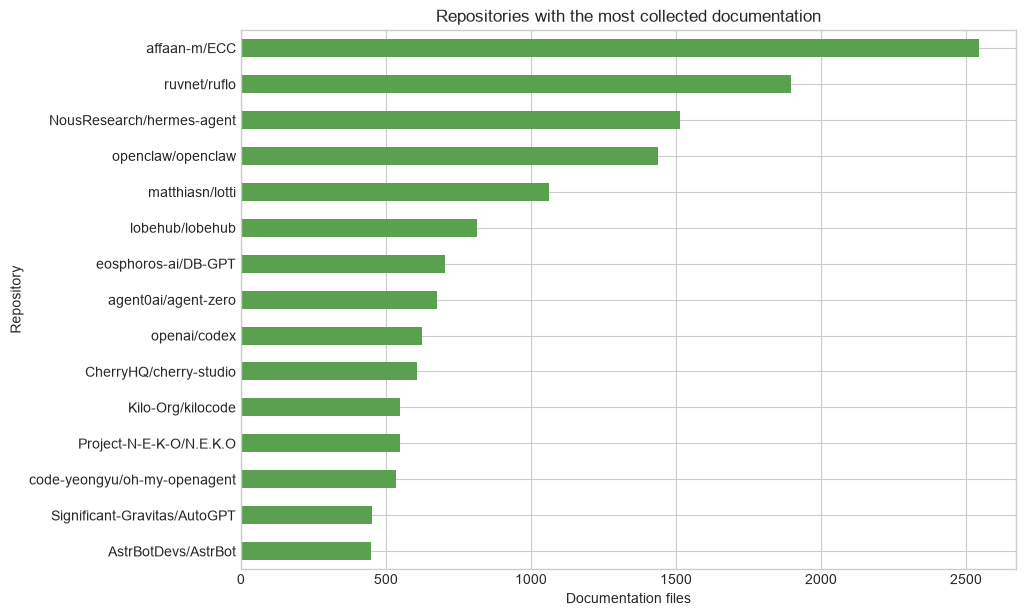

In [6]:
repo_summary = (
    df.groupby(["repository", "repository_url"], as_index=False)
      .agg(
          documentation_files=("path", "size"),
          total_characters=("characters", "sum"),
          median_characters=("characters", "median"),
          unique_directories=("directory", "nunique"),
          root_files=("is_root_file", "sum"),
      )
      .sort_values(["documentation_files", "total_characters"], ascending=False)
)
repo_summary["total_characters"] = repo_summary["total_characters"].astype(int)
repo_summary["median_characters"] = repo_summary["median_characters"].astype(int)
display(repo_summary.head(TOP_N))

chart_data = repo_summary.head(15).sort_values("documentation_files")
ax = chart_data.plot.barh(x="repository", y="documentation_files", legend=False, figsize=(10, 7), color="#59A14F")
ax.set(xlabel="Documentation files", ylabel="Repository", title="Repositories with the most collected documentation")
plt.show()

## File types, locations, and content size

,extension,files
0,.md,17240
1,.mdx,1945
2,.txt,1326
3,.rst,35
4,.markdown,19


,location,files
0,docs,6837
1,packages,1153
2,skills,979
3,v3,973
4,website,890
5,plugins,802
6,.agents,747
7,codex-rs,571
8,docs-site,550
9,.claude,513


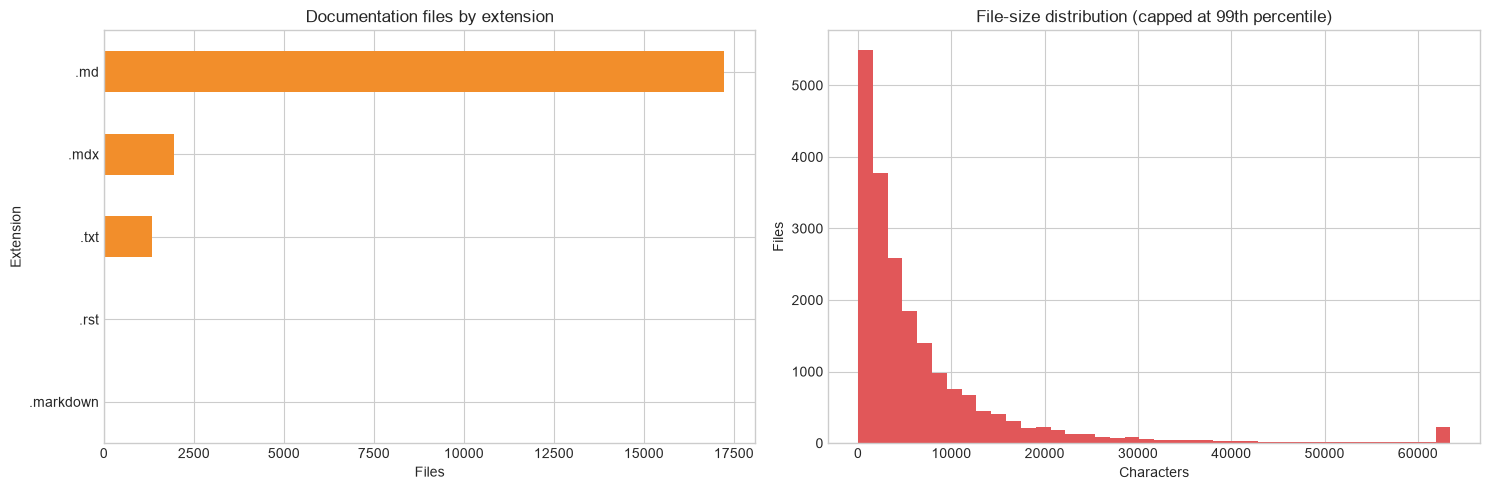

In [7]:
extension_counts = df["extension"].value_counts().rename_axis("extension").reset_index(name="files")
display(extension_counts)

# The first directory component is a compact view of where documentation tends to live.
df["top_level_directory"] = df["path"].map(lambda path: PurePosixPath(path).parts[0] if len(PurePosixPath(path).parts) > 1 else "[root]")
top_level_counts = df["top_level_directory"].value_counts().head(TOP_N).rename_axis("location").reset_index(name="files")
display(top_level_counts)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
extension_counts.sort_values("files").plot.barh(x="extension", y="files", legend=False, ax=axes[0], color="#F28E2B")
axes[0].set(title="Documentation files by extension", xlabel="Files", ylabel="Extension")
df["characters"].clip(upper=df["characters"].quantile(0.99)).plot.hist(bins=40, ax=axes[1], color="#E15759")
axes[1].set(title="File-size distribution (capped at 99th percentile)", xlabel="Characters", ylabel="Files")
plt.tight_layout()
plt.show()

## Suggested follow-up analysis

Useful next questions once the full collection is complete:

- Compare `AGENTS.md`, `SKILL.md`, and `CLAUDE.md` content to identify recurring agent instructions.
- Search for security, installation, architecture, and contribution vocabulary by repository.
- Deduplicate identical files (for example, copied contributor or license guidance) before using the corpus for retrieval or model training.
- Export `repo_summary` and `filename_counts` to CSV if the results are needed in a report.